# Toxic Comments Classification - Data exploration

#### Author: SAFAA ENNACIRI - ENNS11538307                                 
#### Research Director: M. HAKIM LOUNIS

Dataset: Toxic Comment Classification dataset is a dataset of comments from Wikipedia’s talk page edits. It is avaialble at https://data.world/thomasrdavidson/hate-speech-and-offensive-language. 


Exploration and visualization of data set

# 1. Import librairies

In [1]:
# Import Python libraries
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from matplotlib_venn import venn3
from nltk import word_tokenize
import plotly.express as px
from sklearn.model_selection import train_test_split

# 2. Load and explore data set

### Load data

In [2]:
# load the train set
train = pd.read_csv('../../Data/data_set2.csv')
train.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [3]:
# describe the train set
train.describe()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,12681.192027,3.243473,0.280515,2.413711,0.549247,1.110277
std,7299.553863,0.883060,0.631851,1.399459,1.113299,0.462089
min,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,6372.500000,3.000000,0.000000,2.000000,0.000000,1.000000
50%,12703.000000,3.000000,0.000000,3.000000,0.000000,1.000000
75%,18995.500000,3.000000,0.000000,3.000000,0.000000,1.000000
max,25296.000000,9.000000,7.000000,9.000000,9.000000,2.000000


### Total of comments

In [55]:
train.head(30)

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
5,5,3,1,2,0,1,"!!!!!!!!!!!!!!!!!!""@T_Madison_x: The shit just..."
6,6,3,0,3,0,1,"!!!!!!""@__BrighterDays: I can not just sit up ..."
7,7,3,0,3,0,1,!!!!&#8220;@selfiequeenbri: cause I'm tired of...
8,8,3,0,3,0,1,""" &amp; you might not get ya bitch back &amp; ..."
9,9,3,1,2,0,1,""" @rhythmixx_ :hobbies include: fighting Maria..."


In [56]:
# Count number of not toxic comments
not_toxic = len(train[(train['class']==2)])

# Count number of toxic comments
_toxic = len(train)-not_toxic 

In [57]:
# Print total of comments
print("Total of comments = ",len(train))
print("Total of hate and offensive comments = ",_toxic)
print("Total of normal comments = ",not_toxic)

Total of comments =  24783
Total of hate and offensive comments =  20620
Total of normal comments =  4163


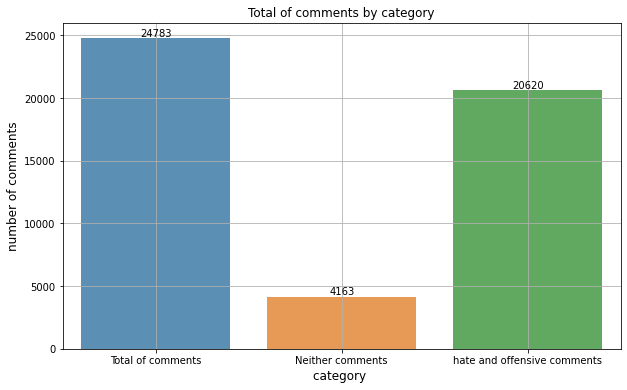

In [58]:
# Plot number of comments by category
plt.figure(figsize = (10,6))
x = ['Total of comments', 'Neither comments', 'hate and offensive comments']
y = [len(train), not_toxic, _toxic]
ax = sns.barplot(x, y, alpha = 0.8)
plt.title("Total of comments by category")
plt.ylabel('number of comments', fontsize = 12)
plt.xlabel('category ', fontsize = 12)

# add text labels
rects = ax.patches
labels = y
for rect, label in zip(rects, labels):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, height + 5, label, ha = 'center', va = 'bottom')   
plt.grid(True)
plt.savefig('../graphs/Total_comments_category.png', bbox_inches='tight')

The majority of  are not labeled.

In [59]:
# Percentage of comments that are not labelled
length = ((not_toxic / len(train))*100)
print('Percentage of comments that are not labelled: {:.4} %'.format(length))

# Percentage of comments that are labelled
print('Percentage of comments that are labelled: {:.4} %'.format(100 - length))

Percentage of comments that are not labelled: 16.8 %
Percentage of comments that are labelled: 83.2 %


###  Number of toxic comments by category

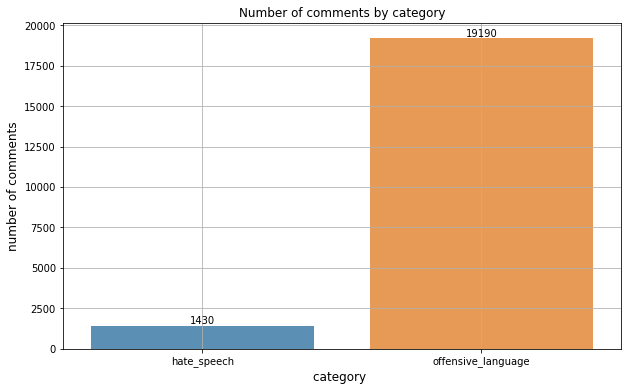

In [60]:
count = train['class'].value_counts() 
hate_speech = count[0]
offensive = count[1]

# Plot number of comments by category
plt.figure(figsize = (10,6))
x = ['hate_speech', 'offensive_language']
y = [hate_speech, offensive]
ax = sns.barplot(x, y, alpha = 0.8)
plt.title("Number of comments by category")
plt.ylabel('number of comments', fontsize = 12)
plt.xlabel('category ', fontsize = 12)

# add text labels
rects = ax.patches
labels = y
for rect, label in zip(rects, labels):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, height + 5, label, ha = 'center', va = 'bottom')   
plt.grid(True)
plt.savefig('../graphs/Number_comments_label.png', bbox_inches='tight')

The most of the comments have toxic label.

In [61]:
# Percentage of toxic comments by category
labels = ['hate_speech', 'offensive_language']
count = [hate_speech, offensive]
for i in range(1,3):
    total = (count[i-1]/len(train))*100
    text = 'Percentage of ' + str(labels[i-1]) + ' comments: {:.4} % \n'
    print(text.format(total))
    
print('Percentage of neither comments: {:.4} %'.format(length))

Percentage of hate_speech comments: 5.77 % 

Percentage of offensive_language comments: 77.43 % 

Percentage of neither comments: 16.8 %


### Detect missing values

In [62]:
# Detect the missing values or NaN values in DataFrame
print('Number of missing comments in comment text column:')
print(train['tweet'].isnull().sum())

Number of missing comments in comment text column:
0


There is no missing comment in train set.

### Distribution of the number of words

In [63]:
# create a numpy array of the length of each comment in the dataset.
tweet = train['tweet']

x = np.array([len(tweet[i]) 
for i in range
    (tweet.shape[0])])
# print lengths of comments
print("""Maximum length of comments: {} characters
        \nMinimum length of the comments: {} characters
        \nAverage length of a comments: {:.2f} characters """.format(x.max(),x.min(),x.mean()))

Maximum length of comments: 754 characters
        
Minimum length of the comments: 5 characters
        
Average length of a comments: 85.44 characters 


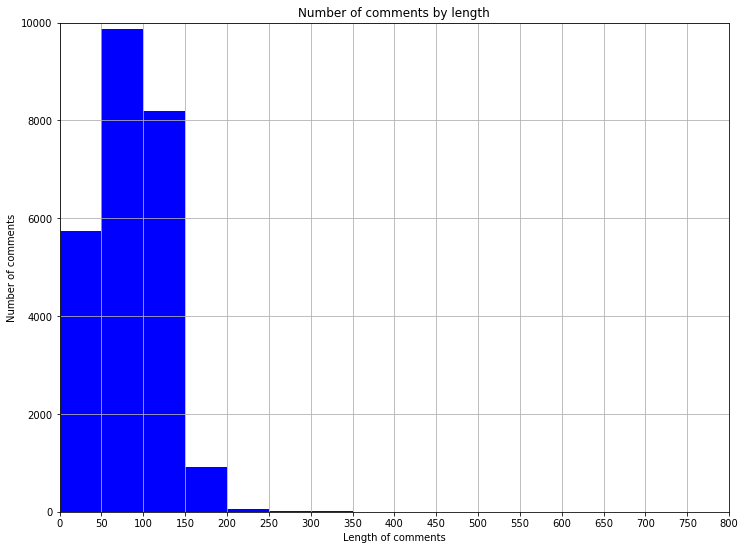

In [64]:
# plot length of comments
plt.figure(figsize = (12,9))
bins= np.arange(0,800,50)
plt.hist(x, bins= bins, color = 'blue')
plt.xlabel('Length of comments')
plt.ylabel('Number of comments') 
plt.title("Number of comments by length")
plt.axis([0, 600, 0, 10000])
plt.xticks([0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800])
plt.grid(True)
plt.savefig('../graphs/Number_comments_length.png', bbox_inches='tight')

The majority of the comments text lengths are less than 150 characters but some comment text lengths can be up to 350 characters.

In [65]:
# Tokenize comment
train['tokenized'] = train.apply(lambda row: word_tokenize(row['tweet']), axis=1)

In [66]:
# Count length of comments after tikenisation
lengths = [len(line) for line in train['tokenized']]
fig = px.histogram(lengths)
fig.show()

In [67]:
sorted_list = []
# Create sorted list of lengths
sorted_list = (sorted(lengths, reverse=True)).copy()
max = sorted_list[0]
min = sorted_list[len(sorted_list)-1]
print('Maximum length: ', max)
print('Minimum length: ', min)
print(len(sorted_list))
print(len(lengths))

Maximum length:  321
Minimum length:  1
24783
24783


In [68]:
len1 = sorted_list[1]
len2 = sorted_list[3]
print(max)
print(len1)
print(len2)
print(lengths.index(max))
print(lengths.index(len1))
print(lengths.index(len2))

321
281
267
17865
13402
1596


In [69]:
# print longest comment
print('comment length:', max)
print(train["tweet"][np.argmax(lengths)])

comment length: 321
RT @TrxllLegend: One good girl is worth a thousand bitches

&#128112; = &#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#128109;&#8230;


In [70]:
# print other longest comment
print('comment length:', len1)
print(train["tweet"][lengths.index(len1)])
print('comment length:', len2)
print(train["tweet"][lengths.index(len2)])

comment length: 281
No summer school? &#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515;&#128515; eat a dick school. Im done with your bitch ass !!!!!!
comment length: 267
&#8220;@Untouchable_T: Never seen so many perfect bitches til I made a Twitter &#128564; but &#128056;&#9749;&#65039;&#8221;&#128175;&#128175;&#128175;&#128175;&#128175;&#128175;&#128175;&#128175;&#128175;&#128175;&#128175;&#128175;&#128175;&#128175;&#128175;&#128175;&#128175;&#128175;&#128175;&#12817

Data must be preprocessing because there is a lot of special characters.

### Cloud

In [71]:
# word frequency analysis
def W_Cloud(token):
    negative_context = train[train[token] == 1]
    negative_text = negative_context.tweet
    threat = pd.Series(negative_text).str.cat(sep=' ')
    wordcloud = WordCloud(width=1600, height=800,
                          max_font_size=200).generate(threat)

    plt.figure(figsize=(15, 10))
    plt.imshow(wordcloud.recolor(colormap="Blues"), interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Most common words assosiated with {token} comment", size=20)
    plt.show()

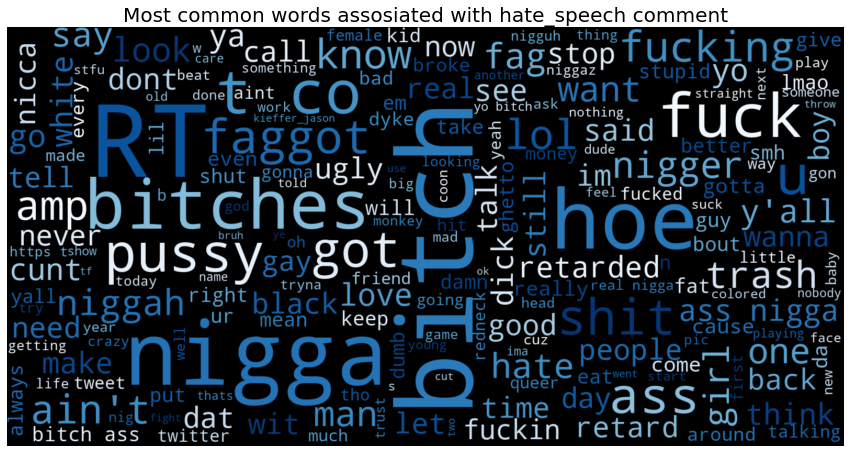

In [72]:
# Most common words assosiated with toxic comment
W_Cloud("hate_speech")

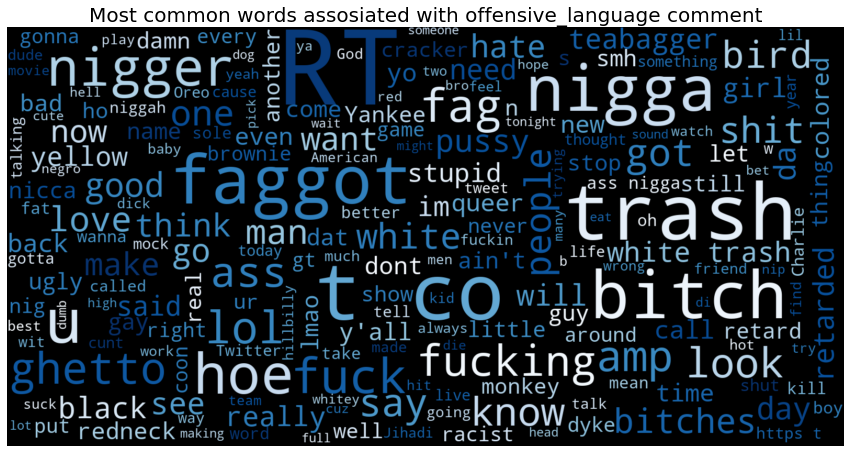

In [73]:
# Most common words assosiated with severe toxic comment
W_Cloud("offensive_language")

Certain words are presents in the two labels.

# 3. Conversion to binary classification

In [4]:
# combine the two classes of toxic comments into one class
def flag_df(df):
    if ((df['class'] == 0) | (df['class'] == 1)):
        return 1
    else:
        return 0

In [5]:
# combine the two toxic classes of train data into one class    
train['tox'] = train.apply(flag_df, axis = 1)

In [6]:
# tox=0: commentaire normale, tox=1: commentarie toxic
train = train[["Unnamed: 0", "tweet", "tox"]]

In [7]:
# describe normal comments
train.describe()

,Unnamed: 0,tox
count,24783.000000,24783.000000
mean,12681.192027,0.832022
std,7299.553863,0.373854
min,0.000000,0.000000
25%,6372.500000,1.000000
50%,12703.000000,1.000000
75%,18995.500000,1.000000
max,25296.000000,1.000000


In [8]:
train.head()

,Unnamed: 0,tweet,tox
0,0,!!! RT @mayasolovely: As a woman you shouldn't...,0
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1
2,2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1
3,3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1
4,4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1


In [11]:
# describe normal comments
normal = train[train.tox==0]
normal.describe()

,Unnamed: 0,tox
count,4163.000000,4163.0
mean,12590.555369,0.0
std,7222.217918,0.0
min,0.000000,0.0
25%,6204.500000,0.0
50%,12759.000000,0.0
75%,18957.000000,0.0
max,25296.000000,0.0


In [12]:
# describe toxic comments
toxic = train[train.tox==1]
toxic.describe()

,Unnamed: 0,tox
count,20620.000000,20620.0
mean,12699.490786,1.0
std,7315.105532,0.0
min,1.000000,1.0
25%,6412.500000,1.0
50%,12701.500000,1.0
75%,19009.250000,1.0
max,25295.000000,1.0


In [13]:
# Count the number of toxic comments by category
toxic_row = train.iloc[:,2:].sum()
rowsums = train.iloc[:,2:].sum(axis = 1)
n = toxic_row.sum()
# print the total of comments
print("Total of comments = ",len(train))
print("Total of toxic comments = ",len(toxic))
print("Total of not toxic comments = ",len(normal))

Total of comments =  24783
Total of toxic comments =  20620
Total of not toxic comments =  4163


Extracting Tweets of all classes

In [14]:
tox_tweets = train[train.tox==1]
neither = train[train.tox==0]
print(tox_tweets.shape)
print(neither.shape)

(20620, 3)
(4163, 3)


# 3. Splitting data

In [16]:
train, test = train_test_split(train, test_size=0.20, random_state=42) 

# 4. Oversampling

In [18]:
train.head()

,Unnamed: 0,tweet,tox
15272,15632,RT @FunSizedYogi: @TheBlackVoice well how else...,1
9351,9609,Funny thing is....it's not just the people doi...,0
20323,20769,"RT @winkSOSA: ""@AintShitSweet__: ""@Rakwon_OGOD...",1
3638,3737,@Jbrendaro30 @ZGabrail @ramsin1995 @GabeEli8 @...,1
20579,21026,S/o that real bitch,1


In [86]:
df=[['I am going to class today','I am going to class today','I am going to class today','I am going to class today','I am going to class today','I am going to class today','I am going to class today','I am going to class today','I am going to class today','I am going to class today','I am not going to class today','I am not going to class today','I am not going to class today','I am not going to class today'],['Positive','Positive','Positive','Positive','Positive','Positive','Positive','Positive','Positive','Positive','Negative','Negative','Negative','Negative']]
df=pd.DataFrame(df)
df=df.transpose()
df.columns=['Features','Class']
df

,Features,Class
0,I am going to class today,Positive
1,I am going to class today,Positive
2,I am going to class today,Positive
3,I am going to class today,Positive
4,I am going to class today,Positive
5,I am going to class today,Positive
6,I am going to class today,Positive
7,I am going to class today,Positive
8,I am going to class today,Positive
9,I am going to class today,Positive


In [24]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
oversample = RandomOverSampler(sampling_strategy='minority')
# fit and apply the transform
X_train, y_train = oversample.fit_resample(train['tweet'].values.reshape(-1,1), train['tox'])
# summarize class distribution
print(Counter(y_train))

Counter({1: 16498, 0: 16498})


In [34]:
train_df = pd.DataFrame(X_train)
train_df['tox'] = y_train
train_df.columns = ['tweet', 'tox']
#train_df['tweet'] =x_train_res


In [35]:
train_df

,tweet,tox
0,RT @FunSizedYogi: @TheBlackVoice well how else...,1
1,Funny thing is....it's not just the people doi...,0
2,"RT @winkSOSA: ""@AintShitSweet__: ""@Rakwon_OGOD...",1
3,@Jbrendaro30 @ZGabrail @ramsin1995 @GabeEli8 @...,1
4,S/o that real bitch,1
...,...,...
32991,RT @LowkeyGado: PND vocals so trash lmao,0
32992,RT @taylorcaniff: I wear beanies all winter lo...,0
32993,damn lol RT @GlobalGrindNews: Janay Rice speak...,0
32994,lmaoooo RT @PhillyTheBoss: Everything on BET i...,0


In [36]:
train_df.shape

(32996, 2)

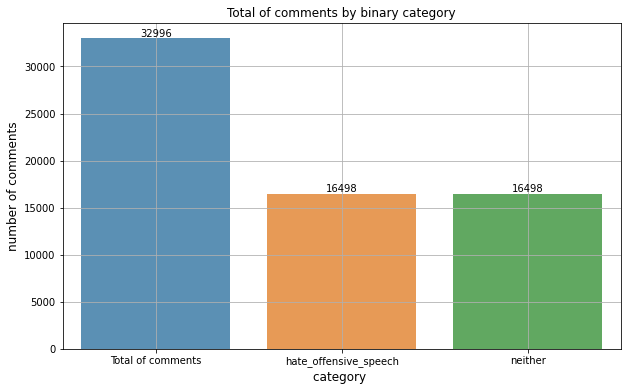

In [38]:
count = train_df['tox'].value_counts() 
tox_tweets = count[1]
neither = count[0]

# Plot number of comments by category
plt.figure(figsize = (10,6))
x = ['Total of comments', 'hate_offensive_speech', 'neither']
y = [(tox_tweets+neither), tox_tweets, neither]
ax = sns.barplot(x, y, alpha = 0.8)
plt.title("Total of comments by binary category")
plt.ylabel('number of comments', fontsize = 12)
plt.xlabel('category ', fontsize = 12)

# add text labels
rects = ax.patches
labels = y
for rect, label in zip(rects, labels):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, height + 5, label, ha = 'center', va = 'bottom')   
plt.grid(True)
plt.savefig('../graphs/Number_comments_label_sample.png', bbox_inches='tight')

In [33]:
train.to_csv('../../Data/train_set2.csv', index=False) 

In [17]:
test.to_csv('../../Data/test_set2.csv', index=False) 